In [9]:
from matplotlib import animation
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import HTML

plt.rcParams['animation.embed_limit'] = 2**128

class Mass(object):
    """
    Class storing information about a mass, including position, and velocity. 

    Data Attributes:
        mass
        position
        velocity
   
    """
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = np.array(position)
        self.velocity = np.array(velocity)

class System():
    def __init__(self, Masses: list[Mass], Natural_units = True, epsilon=0.01):
        self.N = len(Masses)
        self.sys = Masses
        self.epsilon = epsilon

        self.masses = np.array([m.mass for m in Masses])
        self.positions = np.array([m.position for m in Masses])
        self.velocities = np.array([m.velocity for m in Masses])

        if Natural_units:
            self.G = 4 * np.pi * np.pi
        else:
            self.G = 6.67430e-11

        self.trajectory = None

    def acc(self, X, t):
        """This function calculates acceleration using Newtons law of gravitation, given the positions, X of N masses"""

        atot = np.zeros((self.N,3))

        for i in range(self.N):

            for j in range(self.N):
                if j == i:
                    continue

                r_vec = X[j] - X[i] #Calculate displacement between mass i and j
                r = np.linalg.norm(r_vec)

                if r > 0: 

                    #acceleration of mass i due to mass j
                    a_ij = self.G * self.masses[j] * r_vec / (r**2 + self.epsilon**2)**(3/2)

                    atot[i] += a_ij

        return atot
    


    
    def rk4(self, t, acc_func = acc):
        """This function solves the motion of a system of masses using the Runge-Kutta 4th order method"""
        dt = t[1] - t[0]   

        x = self.positions
        v = self.velocities

        k1v  = dt * acc_func(self, x, t[0])
        k1x = dt * v

        k2v = dt * acc_func(self,x + k1x/2, t[0] + dt/2)
        k2x = dt * (v + k1v/2) 

        k3v = dt * acc_func(self,x + k2x/2, t[0] + dt/2)
        k3x = dt * (v + k2v/2)

        k4v = dt * acc_func(self,x + k3x, t[0] + dt)
        k4x = dt * (v + k3v)

        #Allocating space for trajectory
        xtraj = np.zeros((len(t), self.N, 3))
        vtraj = np.zeros((len(t), self.N, 3))
        
        #Setting initial position and velocity
        xtraj[0] = x
        vtraj[0] = v

        for i in range(1, len(t)):
            term2x = 1/6 * (k1x + 2*k2x + 2*k3x + k4x)
            term2v = 1/6 * (k1v + 2*k2v + 2*k3v + k4v)

            x = x + term2x                                                            
            v = v + term2v

            self.positions = x
            self.velocities = v
            
            k1v  = dt * acc_func(self,x, t[i])
            k1x = dt * v

            k2v = dt * acc_func(self,x + k1x/2, t[i] + dt/2)
            k2x = dt * (v + k1v/2) 

            k3v = dt * acc_func(self,x + k2x/2, t[i] + dt/2)
            k3x = dt * (v + k2v/2)

            k4v = dt * acc_func(self,x + k3x, t[i] + dt)
            k4x = dt * (v + k3v)

            xtraj[i] = x
            vtraj[i] = v

        #Combine into a single array of shape (len(t), N, 6)
        ptraj = np.concatenate((xtraj, vtraj), axis = 2)
        self.trajectory = ptraj

        return ptraj
    
    def leapfrog(self, t, acc_func = acc):
        """This function solves the motion of a system of masses using the leapfrog method."""
        dt = t[1] - t[0]

        x = self.positions
        v = self.velocities 

        a = acc_func(self,x, t[0])

        #first half step for velocity, using acceleration at initial positions
        v_half = v + a * dt / 2

        #Allocating space for trajectory
        xtraj = np.zeros((len(t), self.N, 3))
        vtraj = np.zeros((len(t), self.N, 3))

        #Setting initial position and velocity (initial v_half)
        xtraj[0] = x
        vtraj[0] = v_half

        for i in range(1, len(t)):

            x = x + v_half * dt

            a = acc_func(self,x, t)
        
            v_half = v_half + a * dt

            self.positions = x
            self.velocities = v_half

            xtraj[i] = x
            vtraj[i] = v_half

        #Combine into a single array of shape (len(t), N, 6)
        ptraj = np.concatenate((xtraj, vtraj), axis = 2)

        self.trajectory = ptraj

        return ptraj
    

    
    
    def plot(self):
        """This function plots a trajectory using matplotlib in 3d. The view angle can be altered using elev and azim input parameters"""

        
        fig, ax = plt.subplots()
        ax.set_xlabel('X(AU)')
        ax.set_ylabel('Y(AU)')


        positions = self.trajectory[:,:,:2]

        for i in range(self.N):
            ax.plot(positions[:,i,0], positions[:,i,1])
        plt.show()



    def energy(self):
        kin = 0
        pot = 0
        for i in range(self.N):
            kin += 1/2*self.masses[i]*(np.linalg.norm(self.velocities[i]))**2
            for j in range(self.N):
                if i < j:
                    pot += self.G*self.masses[i]*self.masses[j]/(np.linalg.norm(self.positions[i]-self.positions[j]))
        return kin-pot
        
        

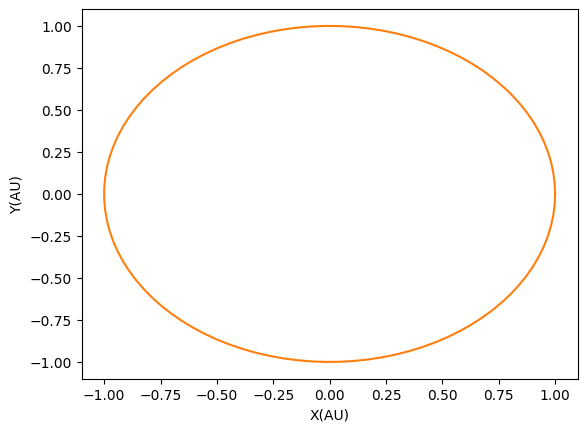

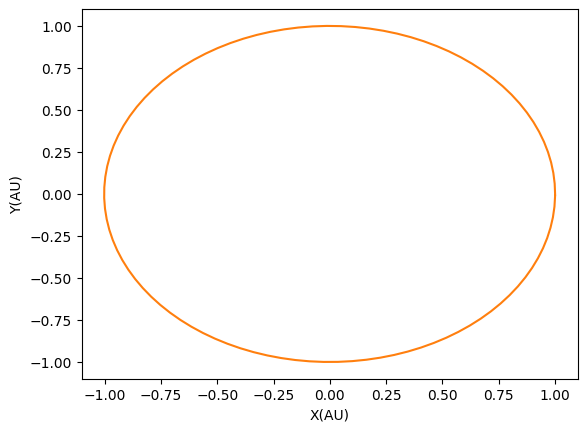

In [10]:
sun = Mass(1, np.zeros(3), np.zeros(3))
earth = Mass(3.00274e-6, np.array([1,0,0]), np.array([0,2*np.pi,0]))

essys = System([sun, earth])
essys.rk4(np.linspace(0, 1, 100))
essys.plot()

essys.leapfrog(np.linspace(0, 1, 100))
essys.plot()

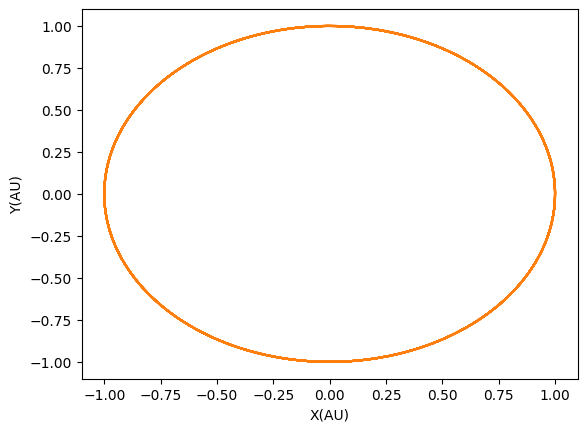

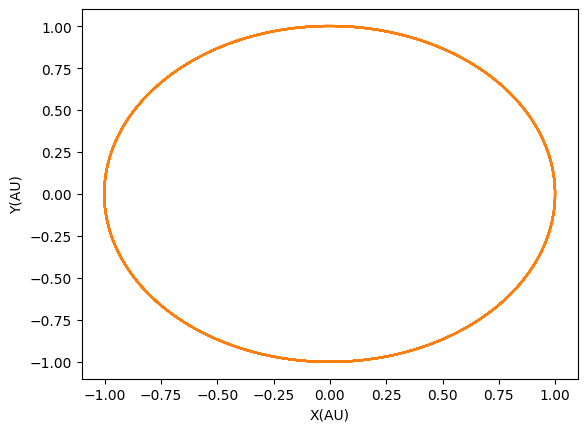

In [16]:
essys = System([sun, earth])

essys.rk4(np.linspace(0, 10, 1000))
essys.plot()

essys.leapfrog(np.linspace(0, 10, 1000))
essys.plot()